# Unusual Seasons — GMU Cherry (Yedoensis & Sargentii)

Identifies observations that correspond to **climatologically unusual seasons**: years in which
bloom timing departs substantially from what is expected at that location and variety.

A season is considered unusual when its bloom DOY z-score (relative to the long-term site
climatology) exceeds a configurable threshold.

Key questions:
1. **Which individual observations are outliers?**
2. **Which years are systemically unusual** — early or late across both varieties and many sites?
3. **Are unusual years spatially clustered**, or do they reflect a Japan-wide signal?
4. **Are the anomalies variety-consistent?** — if both yedoensis and sargentii bloom early
   in year X, it is likely a genuine climate anomaly rather than a data error.
5. **Temperature check** — do bloom anomalies align with winter/spring temperature anomalies?

## Config

In [1]:
OBS_KEY           = 'gmu_0'
YEAR_MIN          = 1986
YEAR_MAX          = 2024

# Minimum years of data at a location to compute a reliable climatology
MIN_CLIM_YEARS    = 5

# |z-score| threshold to flag an observation as unusual
Z_THRESH          = 2.5

# Also flag using IQR method (observation outside Q1 - k*IQR or Q3 + k*IQR)
IQR_K             = 2.5

# Set to False to include observations removed as outliers by default preprocessing
REMOVE_OUTLIERS   = False

# Temperature download (requires OpenMeteo; slow on first run)
DOWNLOAD_TEMPERATURE = False


## 1. Load data

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

from pysephone.constants import KEY_OBS_TYPE, KEY_OBSERVATIONS, KEY_SPECIES_ID, KEY_FEATURES
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.preprocessing.gmu_cherry import get_gmu_cherry_dataset_japan
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.models.util.func_phenology import func_chilling_days

# species_id 0 = Prunus yedoensis (Somei-yoshino)
# species_id 1 = Prunus sargentii
SPECIES_NAMES = {0: 'Prunus yedoensis', 1: 'Prunus sargentii'}

cal       = Calendar(default_start='10-01', default_length=365)
features  = OpenMeteoFeatures(calendar=cal) if DOWNLOAD_TEMPERATURE else None
providers = [features] if features else []

dfs = get_gmu_cherry_dataset_japan(
    remove_outliers=REMOVE_OUTLIERS,
    datetime_observations=True,
)
obs = Observations(dfs['data'], dfs['locations'])

# Filter to yedoensis (0) and sargentii (1) only
obs = obs.select_species([('GMU_cherry', 0), ('GMU_cherry', 1)])

# Apply year filter
obs = obs.select_years(list(range(YEAR_MIN, YEAR_MAX + 1)))

ds = Dataset(obs, calendar=cal, feature_providers=providers)

df_raw   = obs._df_y.copy()
df_bloom = df_raw.xs(OBS_KEY, level=KEY_OBS_TYPE).copy()
df_bloom['doy'] = df_bloom[KEY_OBSERVATIONS].dt.dayofyear
df_bloom = df_bloom.reset_index()

locs = obs._df_y_loc.reset_index()
df   = df_bloom.merge(locs, on=['src', 'loc_id'], how='left')
df['species_name'] = df[KEY_SPECIES_ID].map(SPECIES_NAMES)

print(f'{len(df)} observations | '
      f'{df["loc_id"].nunique()} locations | '
      f'{df["year"].nunique()} years | '
      f'{df[KEY_SPECIES_ID].nunique()} varieties')
print(df.groupby('species_name')['loc_id'].agg(['count','nunique'])
        .rename(columns={'count':'obs','nunique':'locations'}))


2331 observations | 79 locations | 36 years | 2 varieties
                   obs  locations
species_name                     
Prunus sargentii   225          8
Prunus yedoensis  2106         71


## 2. Site-level climatology and anomaly scores

For each (variety, location) pair with at least `MIN_CLIM_YEARS` years of data, compute the
long-term mean and standard deviation of bloom DOY. Each observation then receives:
- **`anom_days`**: observed DOY − site mean (signed, in days)
- **`anom_z`**: anom_days / site std (z-score)

Observations at pairs with fewer than `MIN_CLIM_YEARS` years are retained but have `NaN` anomaly scores.

In [3]:
# ── Site climatology ────────────────────────────────────────────────────
clim = (
    df.groupby(['species_name', 'loc_id'])['doy']
      .agg(clim_mean='mean', clim_std='std', n_clim='count')
      .reset_index()
)
# Only use sites with enough years for a reliable std
clim.loc[clim['n_clim'] < MIN_CLIM_YEARS, ['clim_mean', 'clim_std']] = np.nan

df = df.merge(clim, on=['species_name', 'loc_id'], how='left')
df['anom_days'] = df['doy'] - df['clim_mean']
df['anom_z']    = df['anom_days'] / df['clim_std']

# ── Flag unusual observations ────────────────────────────────────────────
df['unusual_z']   = df['anom_z'].abs() > Z_THRESH
df['unusual_dir'] = np.where(
    df['anom_z'] >  Z_THRESH, 'late',
    np.where(df['anom_z'] < -Z_THRESH, 'early', 'normal')
)

# IQR method (per variety, pooled across all sites)
def _iqr_flag(series, k=IQR_K):
    q25, q75 = series.quantile([0.25, 0.75])
    iqr = q75 - q25
    return (series < q25 - k * iqr) | (series > q75 + k * iqr)

df['unusual_iqr'] = (
    df.groupby('species_name')['anom_days']
      .transform(_iqr_flag)
)

df['unusual'] = df['unusual_z'].fillna(False) | df['unusual_iqr'].fillna(False)

n_scored  = df['anom_z'].notna().sum()
n_unusual = df['unusual_z'].sum()
n_iqr     = df['unusual_iqr'].sum()
print(f'Observations with anomaly score: {n_scored} / {len(df)}')
print(f'Unusual by z-score (|z| > {Z_THRESH}):  {n_unusual}  ({n_unusual/n_scored:.1%})')
print(f'Unusual by IQR (k={IQR_K}):             {n_iqr}  ({n_iqr/n_scored:.1%})')

species_order = ['Prunus yedoensis', 'Prunus sargentii']
palette = {'Prunus yedoensis': '#e8a0b4', 'Prunus sargentii': '#8fbdd3'}


Observations with anomaly score: 2331 / 2331
Unusual by z-score (|z| > 2.5):  6  (0.3%)
Unusual by IQR (k=2.5):             0  (0.0%)


## 3. Anomaly distribution per variety

Distribution of site-adjusted DOY anomalies. The z-score threshold is shown as dashed lines.

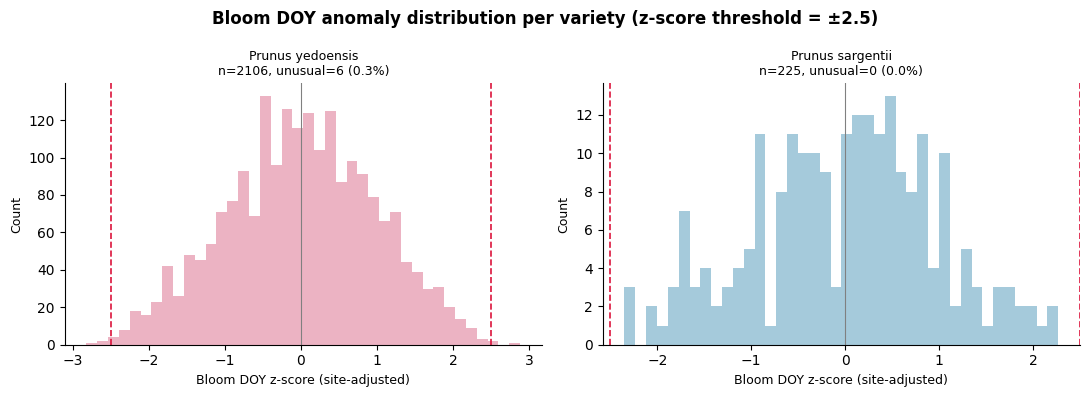

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
fig.suptitle(f'Bloom DOY anomaly distribution per variety '
             f'(z-score threshold = ±{Z_THRESH})',
             fontsize=12, fontweight='bold')

for ax, sp in zip(axes, species_order):
    sub = df[df['species_name'] == sp]['anom_z'].dropna()
    n_out = (sub.abs() > Z_THRESH).sum()
    ax.hist(sub, bins=40, color=palette[sp], alpha=0.80, edgecolor='none')
    ax.axvline(-Z_THRESH, color='crimson', lw=1.2, ls='--')
    ax.axvline( Z_THRESH, color='crimson', lw=1.2, ls='--')
    ax.axvline(0, color='grey', lw=0.8)
    ax.set_title(f'{sp}\nn={len(sub)}, unusual={n_out} ({n_out/len(sub):.1%})',
                 fontsize=9)
    ax.set_xlabel('Bloom DOY z-score (site-adjusted)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Which years are systemically unusual?

A year is systemically unusual if both varieties and many sites simultaneously show anomalous
bloom timing. This is a strong signal of a Japan-wide climate event (e.g. an exceptionally
warm spring).

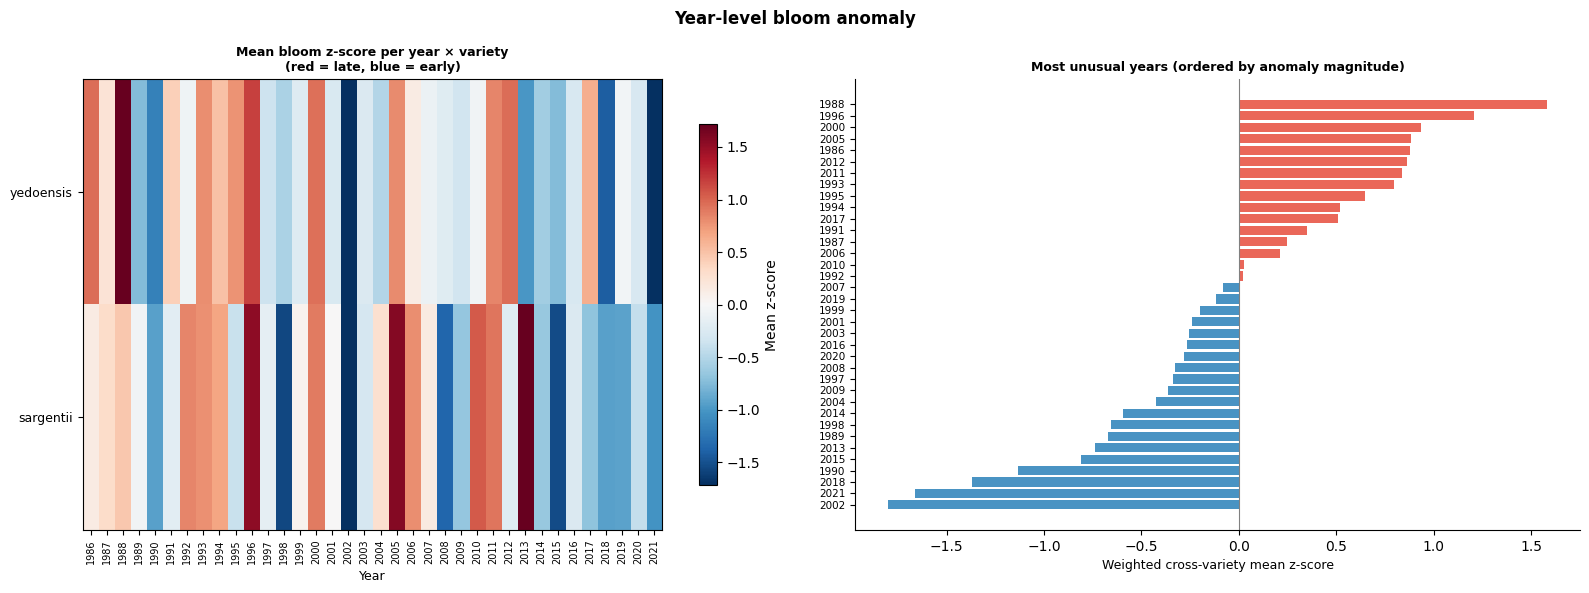

Most extreme years (weighted cross-variety mean z-score):
  2002  EARLY  mean z = -1.80  (n_obs=73)
  2021  EARLY  mean z = -1.66  (n_obs=46)
  2018  EARLY  mean z = -1.37  (n_obs=46)
  1990  EARLY  mean z = -1.13  (n_obs=79)
  2015  EARLY  mean z = -0.81  (n_obs=46)
  1986  LATE   mean z = +0.88  (n_obs=79)
  2005  LATE   mean z = +0.88  (n_obs=73)
  2000  LATE   mean z = +0.94  (n_obs=75)
  1996  LATE   mean z = +1.21  (n_obs=78)
  1988  LATE   mean z = +1.58  (n_obs=79)


In [5]:
# ── Year × variety mean z-score ────────────────────────────────────────
yr_sp_z = (
    df.groupby(['year', 'species_name'])['anom_z']
      .agg(mean_z='mean', n='count')
      .reset_index()
)

mat_z = yr_sp_z.pivot(index='year', columns='species_name', values='mean_z')
mat_z = mat_z.reindex(columns=species_order)

# Weight by number of contributing locations
year_mean_z = (
    yr_sp_z.groupby('year')
      .apply(lambda g: np.average(g['mean_z'].dropna(),
                                   weights=g.loc[g['mean_z'].notna(), 'n']))
      .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Year-level bloom anomaly', fontsize=12, fontweight='bold')

# — Heatmap ───────────────────────────────────────────────────────────
ax = axes[0]
vmax = np.nanpercentile(mat_z.abs().values, 95)
im = ax.imshow(mat_z.values.T, cmap='RdBu_r', aspect='auto',
               vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean z-score', shrink=0.8)
ax.set_xticks(range(len(mat_z.index)))
ax.set_xticklabels(mat_z.index, rotation=90, fontsize=7)
ax.set_yticks(range(len(species_order)))
ax.set_yticklabels([s.split()[-1] for s in species_order], fontsize=9)
ax.set_xlabel('Year', fontsize=9)
ax.set_title('Mean bloom z-score per year × variety\n'
             '(red = late, blue = early)', fontsize=9, fontweight='bold')

# — Weighted cross-variety mean z bar chart ────────────────────────────
ax = axes[1]
colors = ['#e74c3c' if v > 0 else '#2980b9' for v in year_mean_z.values]
ax.barh(range(len(year_mean_z)), year_mean_z.values, color=colors, alpha=0.85)
ax.axvline(0, color='grey', lw=0.8)
ax.set_yticks(range(len(year_mean_z)))
ax.set_yticklabels(year_mean_z.index.astype(str), fontsize=7.5)
ax.set_xlabel('Weighted cross-variety mean z-score', fontsize=9)
ax.set_title('Most unusual years (ordered by anomaly magnitude)',
             fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Most extreme years (weighted cross-variety mean z-score):')
extreme = pd.concat([year_mean_z.head(5), year_mean_z.tail(5)])
for yr, z in extreme.items():
    direction = 'EARLY' if z < 0 else 'LATE '
    y_row = yr_sp_z[yr_sp_z['year'] == yr]
    n_locs = y_row['n'].sum()
    print(f'  {int(yr)}  {direction}  mean z = {z:+.2f}  (n_obs={n_locs})')


## 5. Variety consistency

If both yedoensis and sargentii bloom early/late in the same year, the signal is almost
certainly a genuine climate anomaly. If only one variety is flagged, it may reflect
species-specific phenology or a local data issue.

Yedoensis–Sargentii mean-z correlation: r = 0.532


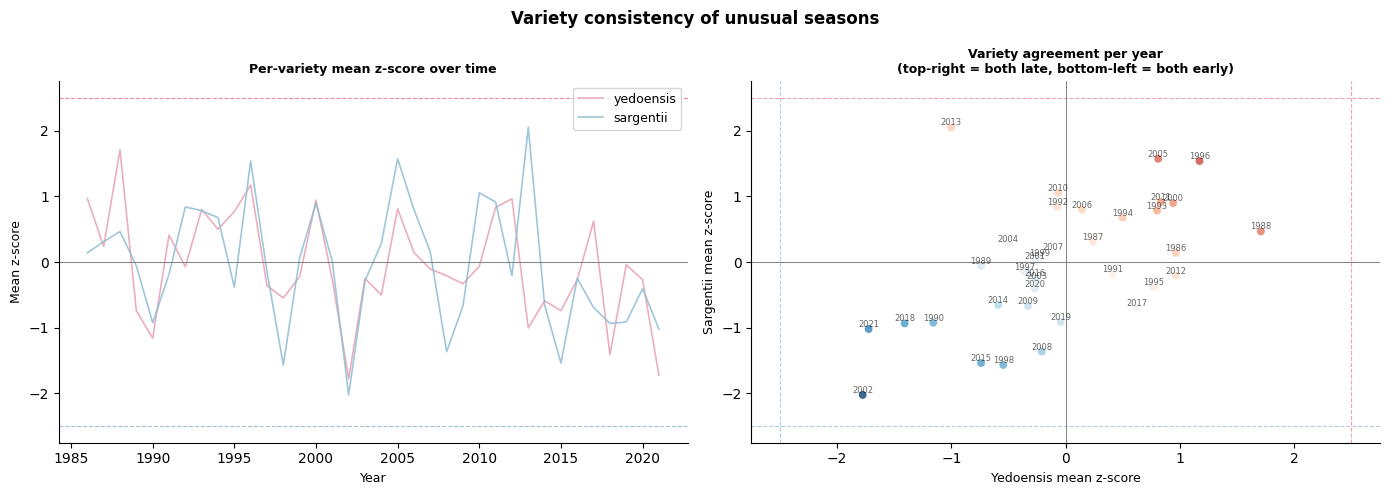

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Variety consistency of unusual seasons',
             fontsize=12, fontweight='bold')

# — Both varieties' mean z per year ────────────────────────────────────
ax = axes[0]
for sp, color in palette.items():
    sub = mat_z[sp].dropna()
    ax.plot(sub.index, sub.values, color=color, lw=1.2,
            label=sp.split()[-1], alpha=0.85)
ax.axhline(0, color='grey', lw=0.7)
ax.axhline( Z_THRESH, color='crimson', lw=0.8, ls='--', alpha=0.5)
ax.axhline(-Z_THRESH, color='steelblue', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Mean z-score', fontsize=9)
ax.set_title('Per-variety mean z-score over time', fontsize=9, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# — Agreement scatter: yedoensis z vs sargentii z ─────────────────────
ax = axes[1]
both = mat_z.dropna()
vmax = both.abs().max().max()
ax.scatter(both['Prunus yedoensis'], both['Prunus sargentii'],
           c=both.mean(axis=1), cmap='RdBu_r',
           vmin=-vmax, vmax=vmax, s=35, alpha=0.8, edgecolors='white', lw=0.3)
for yr, row in both.iterrows():
    ax.annotate(str(int(yr)), (row['Prunus yedoensis'], row['Prunus sargentii']),
                fontsize=6, ha='center', va='bottom', alpha=0.6)
ax.axhline(0, color='grey', lw=0.7); ax.axvline(0, color='grey', lw=0.7)
ax.axhline( Z_THRESH, color='crimson', lw=0.8, ls='--', alpha=0.4)
ax.axhline(-Z_THRESH, color='steelblue', lw=0.8, ls='--', alpha=0.4)
ax.axvline( Z_THRESH, color='crimson', lw=0.8, ls='--', alpha=0.4)
ax.axvline(-Z_THRESH, color='steelblue', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('Yedoensis mean z-score', fontsize=9)
ax.set_ylabel('Sargentii mean z-score', fontsize=9)
ax.set_title('Variety agreement per year\n'
             '(top-right = both late, bottom-left = both early)',
             fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

r = both.corr().loc['Prunus yedoensis', 'Prunus sargentii']
print(f'Yedoensis–Sargentii mean-z correlation: r = {r:.3f}')

plt.tight_layout()
plt.show()


## 6. Spatial distribution of unusual observations

Map of all unusual observations (|z| > threshold), coloured by direction
(early = blue, late = red). Spatial clustering suggests a regional climate event.

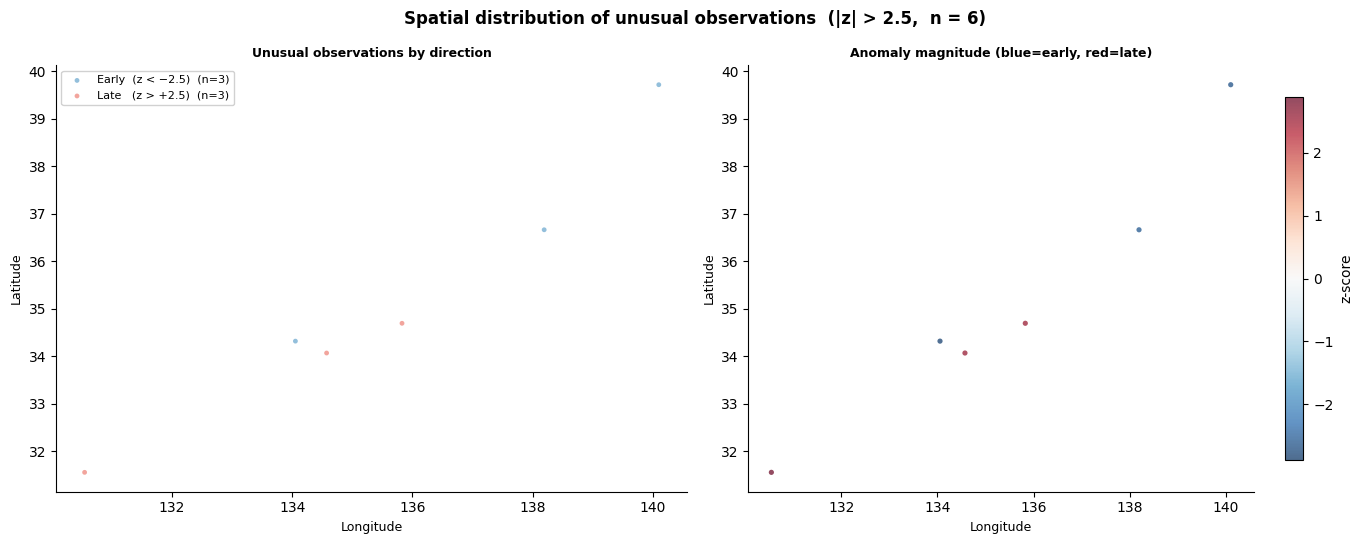

Unusual obs by variety:
                  n_unusual  n_early  n_late  mean_anom
species_name                                           
Prunus yedoensis        6.0      3.0     3.0  -0.916667
Prunus sargentii        NaN      NaN     NaN        NaN


In [7]:
unusual_df = df[df['unusual_z'] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'Spatial distribution of unusual observations  '
             f'(|z| > {Z_THRESH},  n = {len(unusual_df)})',
             fontsize=12, fontweight='bold')

ax = axes[0]
for direction, color, label in [
        ('early', '#2980b9', 'Early  (z < −{})'.format(Z_THRESH)),
        ('late',  '#e74c3c', 'Late   (z > +{})'.format(Z_THRESH))]:
    sub = unusual_df[unusual_df['unusual_dir'] == direction]
    ax.scatter(sub['lon'], sub['lat'], c=color, s=12, alpha=0.5,
               label=f'{label}  (n={len(sub)})', edgecolors='none')
ax.set_xlabel('Longitude', fontsize=9); ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('Unusual observations by direction', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
vmax = unusual_df['anom_z'].abs().quantile(0.99)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
sc = ax.scatter(unusual_df['lon'], unusual_df['lat'],
                c=unusual_df['anom_z'], cmap='RdBu_r', norm=norm,
                s=14, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax, label='z-score', shrink=0.85)
ax.set_xlabel('Longitude', fontsize=9); ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('Anomaly magnitude (blue=early, red=late)',
             fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Unusual obs by variety:')
print(unusual_df.groupby('species_name').agg(
    n_unusual=('unusual_z', 'count'),
    n_early=('unusual_dir', lambda x: (x=='early').sum()),
    n_late=('unusual_dir', lambda x: (x=='late').sum()),
    mean_anom=('anom_days', 'mean'),
).reindex(species_order).to_string())


## 7. Deep-dive: most unusual years

For the top-3 most unusual years (by absolute weighted cross-variety mean z-score),
show the spatial distribution and per-variety anomaly.

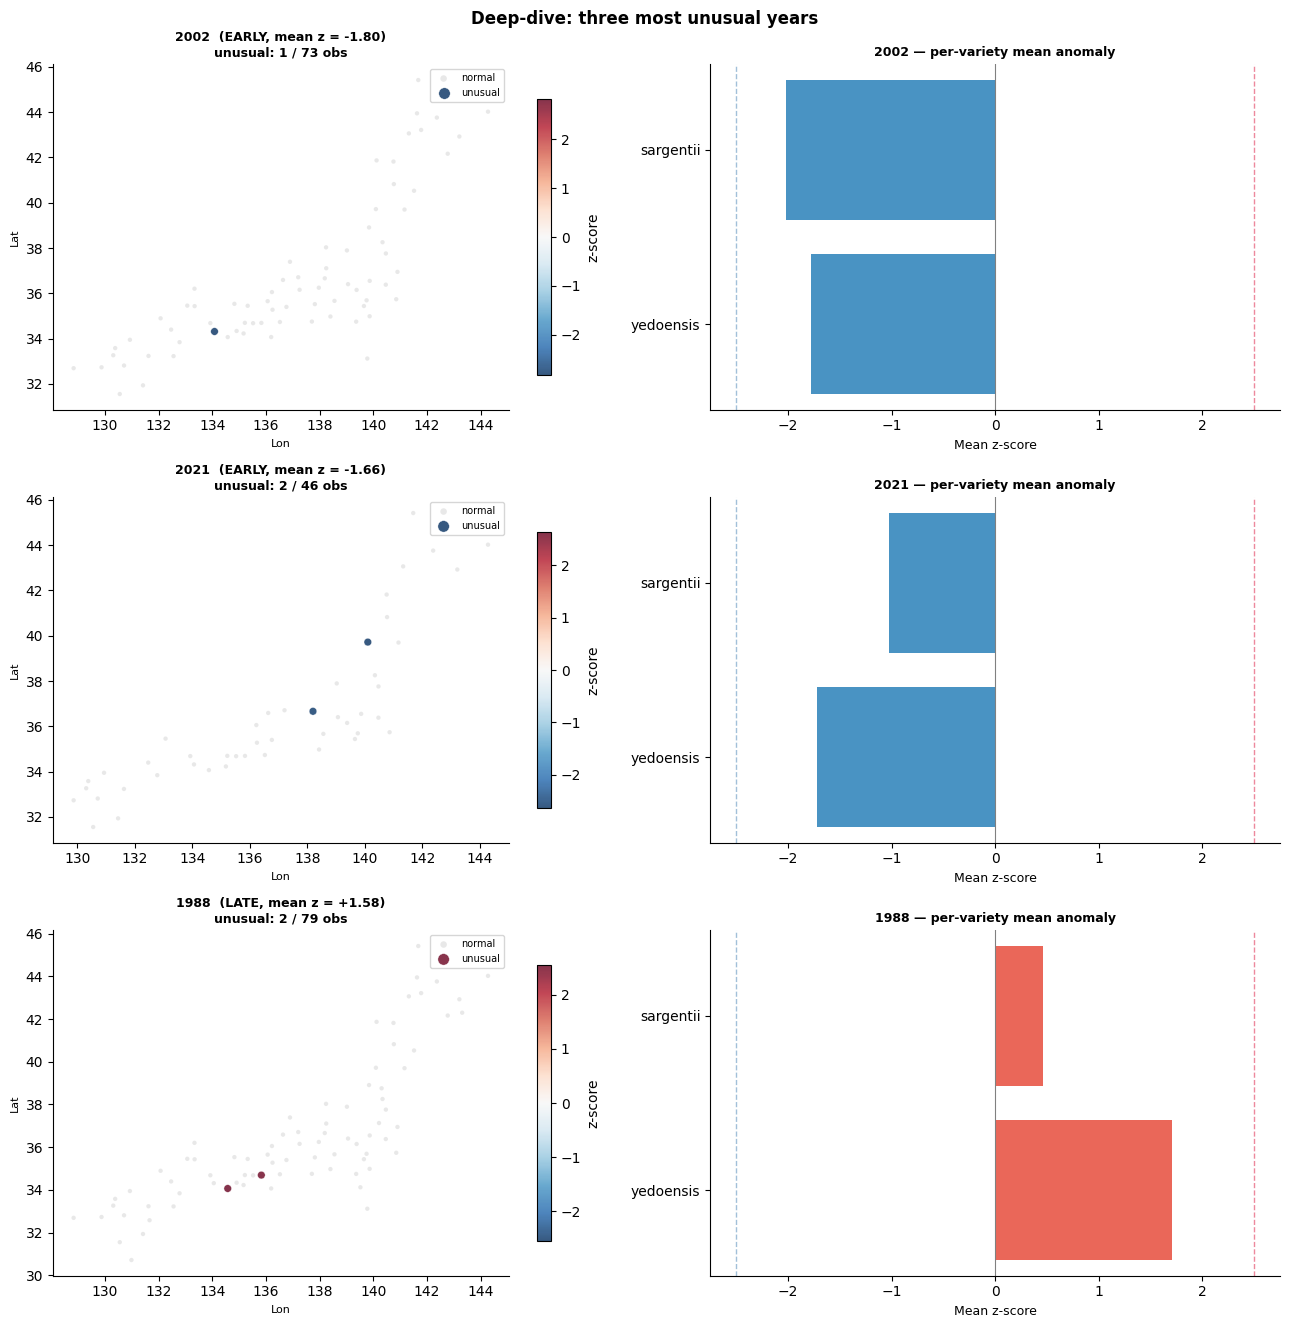

In [8]:
top_years = year_mean_z.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(len(top_years), 2,
                          figsize=(13, 4.5 * len(top_years)))
if len(top_years) == 1:
    axes = [axes]
fig.suptitle('Deep-dive: three most unusual years', fontsize=12, fontweight='bold')

for row_axes, yr in zip(axes, top_years):
    yr_df = df[df['year'] == yr]
    yr_z  = year_mean_z[yr]
    direction = 'EARLY' if yr_z < 0 else 'LATE'

    # — map ─────────────────────────────────────────────────────────────
    ax = row_axes[0]
    yr_u = yr_df[yr_df['unusual_z'] == True]
    yr_n = yr_df[yr_df['unusual_z'] == False]
    ax.scatter(yr_n['lon'], yr_n['lat'], c='lightgrey', s=10, alpha=0.5,
               edgecolors='none', label='normal')
    if len(yr_u) > 0:
        vmax_yr = yr_u['anom_z'].abs().max()
        norm_yr = mcolors.TwoSlopeNorm(vmin=-vmax_yr, vcenter=0, vmax=vmax_yr)
        sc = ax.scatter(yr_u['lon'], yr_u['lat'],
                        c=yr_u['anom_z'], cmap='RdBu_r', norm=norm_yr,
                        s=30, alpha=0.8, edgecolors='white', linewidths=0.3,
                        label='unusual')
        plt.colorbar(sc, ax=ax, label='z-score', shrink=0.8)
    ax.set_title(f'{yr}  ({direction}, mean z = {yr_z:+.2f})\n'
                 f'unusual: {len(yr_u)} / {len(yr_df)} obs',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Lon', fontsize=8); ax.set_ylabel('Lat', fontsize=8)
    ax.legend(fontsize=7, markerscale=1.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # — per-variety anomaly ──────────────────────────────────────────────
    ax = row_axes[1]
    sp_z = mat_z.loc[yr].reindex(species_order) if yr in mat_z.index else pd.Series([np.nan]*2, index=species_order)
    colors_bar = ['#e74c3c' if v > 0 else '#2980b9'
                  if not np.isnan(v) else 'lightgrey'
                  for v in sp_z]
    ax.barh(range(len(species_order)), sp_z.fillna(0),
            color=colors_bar, alpha=0.85)
    ax.axvline(0, color='grey', lw=0.8)
    ax.axvline( Z_THRESH, color='crimson', lw=1, ls='--', alpha=0.5)
    ax.axvline(-Z_THRESH, color='steelblue', lw=1, ls='--', alpha=0.5)
    ax.set_yticks(range(len(species_order)))
    ax.set_yticklabels([s.split()[-1] for s in species_order], fontsize=10)
    ax.set_xlabel('Mean z-score', fontsize=9)
    ax.set_title(f'{yr} — per-variety mean anomaly', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 8. Temperature check (optional)

Set `DOWNLOAD_TEMPERATURE = True` in the config to download OpenMeteo data. This section
plots bloom anomaly vs winter/spring temperature anomaly, and highlights observations where
bloom is unusual but temperature is not — potential data quality flags.

In [9]:
if not DOWNLOAD_TEMPERATURE:
    print('Set DOWNLOAD_TEMPERATURE = True and re-run to enable this section.')
else:
    ds.download_features(verbose=True)

    temp_rows = {}
    for item in ds.iter_items():
        if OBS_KEY not in item.get('observations_index', {}):
            continue
        key = (item['src'], item['loc_id'], item['year'])
        if key in temp_rows:
            continue
        ts = item[KEY_FEATURES]['temperature_2m_mean'].astype(float)
        temp_rows[key] = {
            'src': item['src'], 'loc_id': item['loc_id'], 'year': item['year'],
            'mean_winter_T': float(ts[:120].mean()),
            'mean_spring_T': float(ts[120:212].mean()),
            'chill_days':    float(func_chilling_days(ts).sum()),
        }

    df_temp = pd.DataFrame(list(temp_rows.values()))
    t_clim = df_temp.groupby('loc_id')[['mean_winter_T', 'mean_spring_T']].transform(
        lambda x: (x - x.mean()) / x.std()
    ).rename(columns={'mean_winter_T': 'winter_T_z', 'mean_spring_T': 'spring_T_z'})
    df_temp = pd.concat([df_temp, t_clim], axis=1)
    df = df.merge(df_temp, on=['src', 'loc_id', 'year'], how='left')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Bloom anomaly vs temperature anomaly', fontsize=12, fontweight='bold')

    for ax, (col, label) in zip(axes[:2], [
            ('winter_T_z', 'Winter T z-score (Oct–Jan)'),
            ('spring_T_z', 'Spring T z-score (Feb–Apr)')]):
        sample = df.dropna(subset=['anom_z', col]).sample(
            min(3000, df[col].notna().sum()), random_state=0)
        ax.scatter(sample[col], sample['anom_z'],
                   c=sample[KEY_SPECIES_ID].map({0: palette['Prunus yedoensis'],
                                                  1: palette['Prunus sargentii']}),
                   s=6, alpha=0.3, edgecolors='none')
        ax.axhline(0, color='grey', lw=0.7); ax.axvline(0, color='grey', lw=0.7)
        r = sample[['anom_z', col]].corr().iloc[0, 1]
        ax.set_xlabel(label, fontsize=9)
        ax.set_ylabel('Bloom z-score', fontsize=9)
        ax.set_title(f'r = {r:.3f}', fontsize=9, fontweight='bold')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[2]
    df['bloom_unusual_temp_normal'] = (
        (df['anom_z'].abs() > Z_THRESH) &
        (df['winter_T_z'].abs() < 1.5) &
        (df['spring_T_z'].abs() < 1.5)
    )
    susp = df[df['bloom_unusual_temp_normal'] == True]
    norm_df = df[df['bloom_unusual_temp_normal'] == False]
    ax.scatter(norm_df.sample(min(2000, len(norm_df)), random_state=0)['lon'],
               norm_df.sample(min(2000, len(norm_df)), random_state=0)['lat'],
               c='lightgrey', s=4, alpha=0.3, edgecolors='none', label='normal')
    ax.scatter(susp['lon'], susp['lat'], c='darkorange', s=25, alpha=0.8,
               edgecolors='none', label=f'unusual bloom, normal T (n={len(susp)})')
    ax.set_xlabel('Longitude', fontsize=9); ax.set_ylabel('Latitude', fontsize=9)
    ax.set_title('Unusual bloom but near-normal temperature',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f'Candidate data quality flags: {len(susp)} observations')


Set DOWNLOAD_TEMPERATURE = True and re-run to enable this section.


## 9. Flagged observations

Summary table of all observations flagged as unusual, sorted by |z-score|.

In [10]:
cols = ['year', 'src', 'loc_id', 'lat', 'lon',
        'species_name', 'doy', 'clim_mean', 'anom_days', 'anom_z',
        'unusual_dir', 'n_clim']
flagged = (
    df[df['unusual_z'] == True][cols]
      .sort_values('anom_z', key=abs, ascending=False)
      .reset_index(drop=True)
)
flagged = flagged.round({'clim_mean': 1, 'anom_days': 1, 'anom_z': 2})
print(f'{len(flagged)} unusual observations (|z| > {Z_THRESH})')
display(flagged.head(30))


6 unusual observations (|z| > 2.5)


,year,src,loc_id,lat,lon,species_name,doy,clim_mean,anom_days,anom_z,unusual_dir,n_clim
0,2020,GMU_cherry,Japan__Kagoshima,31.555000,130.548056,Prunus yedoensis,110,94.7,15.3,2.89,late,36
1,2002,GMU_cherry,Japan__Takamatsu,34.318056,134.054444,Prunus yedoensis,82,94.1,-12.1,-2.82,early,36
2,2021,GMU_cherry,Japan__Akita,39.717500,140.099167,Prunus yedoensis,97,111.3,-14.3,-2.64,early,36
3,2021,GMU_cherry,Japan__Nagano,36.662778,138.192500,Prunus yedoensis,91,105.7,-14.7,-2.59,early,36
4,1988,GMU_cherry,Japan__Tokushima,34.067778,134.573333,Prunus yedoensis,104,94.6,9.4,2.55,late,36
5,1988,GMU_cherry,Japan__Nara,34.693889,135.827778,Prunus yedoensis,105,94.1,10.9,2.53,late,36
